# Spam Message Detection

End-to-end notebook to inspect SMS data quality, train a leak-safe spam detector, evaluate operating performance, and export reusable artifacts.

**Hold-out target:** maximize spam F1 while keeping false positives visible for review.

**Pipeline:** text cleaning → dual TF-IDF features → LinearSVC → probability calibration → validation-selected decision threshold.


## Overview and Goals

This notebook answers four practical questions:

- What does the SMS dataset look like after basic cleaning and duplicate removal?
- Can a simple, reproducible text-classification pipeline separate spam from ham reliably?
- Which examples are still hard for the model, and what failure modes should be monitored?
- Which artifacts can be reused later in a small API, dashboard, or batch scoring job?

The final output is a calibrated spam classifier with metrics, plots, model artifacts, metadata, and review tables saved under `./artifacts/`.


# Config and Imports

In [1]:
import json
import random
import re
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
N_ITER_SEARCH = 20
N_SPLITS = 5

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

ARTIFACT_DIR = Path("./artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.14.6
pandas: 3.0.3
numpy: 2.5.1
matplotlib: 3.11.0
scikit-learn: 1.9.0


# Data Loading

In [2]:
def find_sms_csv() -> Path:
    candidate_paths = [
        Path("data/raw/SPAM text message 20170820 - Data.csv"),
        Path("SPAM text message 20170820 - Data.csv"),
        Path("sms_data/SPAM text message 20170820 - Data.csv"),
        Path("/kaggle/input/spam-text-message-classification/SPAM text message 20170820 - Data.csv"),
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    search_roots = [Path.cwd(), Path("/kaggle/input")]
    filename_pattern = "*SPAM*text*message*Data*.csv"

    for root in search_roots:
        if root.exists():
            matches = sorted(root.rglob(filename_pattern))
            if matches:
                return matches[0]

    raise FileNotFoundError(
        "CSV file was not found. Add the Kaggle dataset or place "
        "`SPAM text message 20170820 - Data.csv` next to the notebook."
    )


csv_path = find_sms_csv()
raw_df = pd.read_csv(csv_path)

print("CSV path:", csv_path)
print("Raw shape:", raw_df.shape)
display(raw_df.head())


CSV path: data/raw/SPAM text message 20170820 - Data.csv
Raw shape: (5572, 2)


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Basic Data Health Checks

In [3]:
def standardize_sms_columns(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data.columns = [c.lower().strip() for c in data.columns]

    if {"v1", "v2"}.issubset(data.columns):
        data = data.rename(columns={"v1": "label", "v2": "text"})
    elif {"category", "message"}.issubset(data.columns):
        data = data.rename(columns={"category": "label", "message": "text"})

    required_columns = {"label", "text"}
    missing_columns = required_columns.difference(data.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    return data[["label", "text"]]


df_raw_standardized = standardize_sms_columns(raw_df)
raw_rows = len(df_raw_standardized)
missing_rows = int(df_raw_standardized[["label", "text"]].isna().any(axis=1).sum())
duplicate_rows = int(df_raw_standardized.duplicated(subset=["label", "text"]).sum())

df = df_raw_standardized.dropna(subset=["label", "text"]).drop_duplicates(subset=["label", "text"]).copy()
df["label"] = df["label"].astype(str).str.strip().str.lower()
df["text"] = df["text"].astype(str).str.strip()

label_map = {"ham": 0, "spam": 1}
invalid_label_rows = int((~df["label"].isin(label_map)).sum())
df = df[df["label"].isin(label_map)].copy()

cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "raw_rows",
            "missing_label_or_text_rows",
            "duplicate_label_text_rows",
            "invalid_label_rows_after_cleaning",
            "final_rows",
            "final_columns",
        ],
        "value": [
            raw_rows,
            missing_rows,
            duplicate_rows,
            invalid_label_rows,
            len(df),
            df.shape[1],
        ],
    }
)

display(cleaning_summary)
display(df.head())
display(df["label"].value_counts().rename_axis("label").reset_index(name="count"))

print("Final shape:", df.shape)
print("\nFinal dataset info:")
df.info()


,metric,value
0,raw_rows,5572
1,missing_label_or_text_rows,0
2,duplicate_label_text_rows,403
3,invalid_label_rows_after_cleaning,0
4,final_rows,5169
5,final_columns,2


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


,label,count
0,ham,4516
1,spam,653


Final shape: (5169, 2)

Final dataset info:
<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5169 non-null   str  
 1   text    5169 non-null   str  
dtypes: str(2)
memory usage: 121.1 KB


# Focused EDA: Class Balance and Message Length

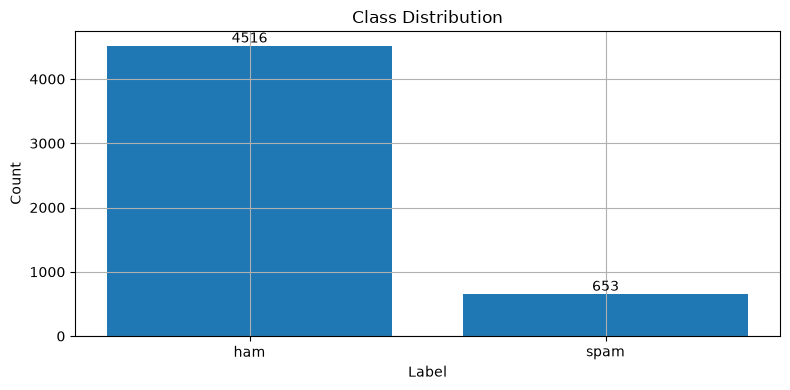

n_chars                         n_words                       
        count    mean median min  max   count   mean median min  max
label                                                               
ham      4516   70.87   53.0   2  910    4516  14.24   11.0   1  171
spam      653  137.66  148.0  13  223     653  23.74   25.0   2   35

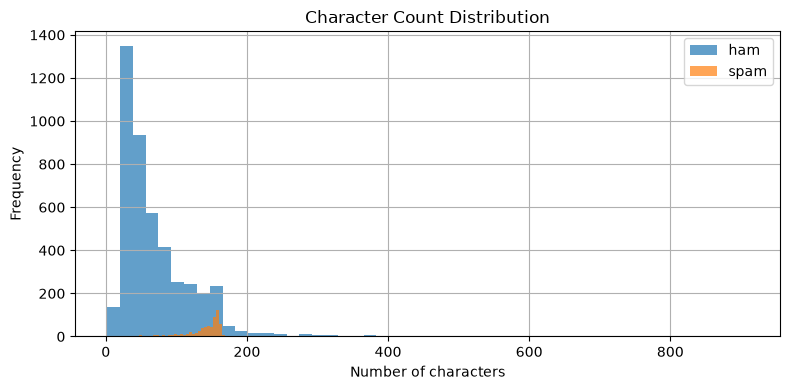

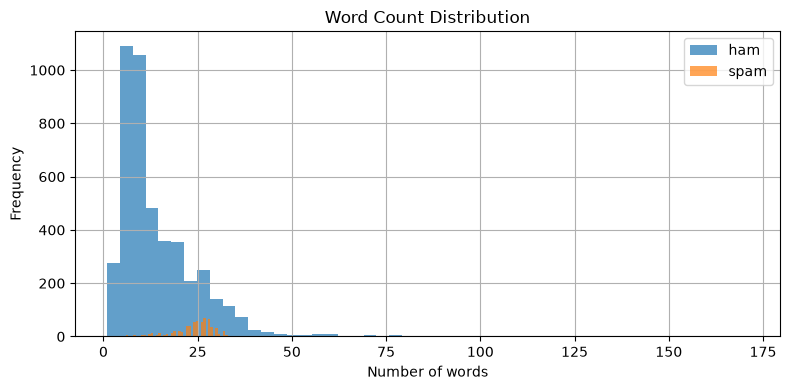

In [4]:
y = df["label"].map(label_map).to_numpy(dtype=int)

counts = pd.Series(y).value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(["ham", "spam"], counts.values)
ax.set_title("Class Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, value in enumerate(counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

def safe_len_tokens(text: str) -> int:
    return len(str(text).split())


df_eda = df.copy()
df_eda["n_chars"] = df_eda["text"].apply(len)
df_eda["n_words"] = df_eda["text"].apply(safe_len_tokens)

length_summary = (
    df_eda.groupby("label")[["n_chars", "n_words"]]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(length_summary)

fig, ax = plt.subplots()
ax.hist(df_eda[df_eda["label"] == "ham"]["n_chars"], bins=50, alpha=0.7, label="ham")
ax.hist(df_eda[df_eda["label"] == "spam"]["n_chars"], bins=50, alpha=0.7, label="spam")
ax.set_title("Character Count Distribution")
ax.set_xlabel("Number of characters")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "char_len_hist.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots()
ax.hist(df_eda[df_eda["label"] == "ham"]["n_words"], bins=50, alpha=0.7, label="ham")
ax.hist(df_eda[df_eda["label"] == "spam"]["n_words"], bins=50, alpha=0.7, label="spam")
ax.set_title("Word Count Distribution")
ax.set_xlabel("Number of words")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "word_len_hist.png", dpi=150, bbox_inches="tight")
plt.show()


# Text Normalization

In [5]:
URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
EMAIL_RE = re.compile(r"[a-zA-Z0-9_.+\-]+@[a-zA-Z0-9\-]+\.[a-zA-Z0-9\-.]+")
PHONE_RE = re.compile(r"\b\+?\d[\d\s\-()]{6,}\b")
MONEY_RE = re.compile(r"(£|\$|€)\s?\d[\d,\.]*")
NUM_RE = re.compile(r"\b\d+\b")


def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = URL_RE.sub(" __url__ ", text)
    text = EMAIL_RE.sub(" __email__ ", text)
    text = PHONE_RE.sub(" __phone__ ", text)
    text = MONEY_RE.sub(" __money__ ", text)
    text = NUM_RE.sub(" __number__ ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


sample_text = df["text"].iloc[0]
print("Before:", sample_text)
print("After :", normalize_text(sample_text))


Before: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
After : go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


# Train/Test Split

In [6]:
X_df = df[["text"]]
y = df["label"].map(label_map).to_numpy(dtype=int)

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "split": ["overall", "train", "test"],
        "rows": [len(X_df), len(X_train_df), len(X_test_df)],
        "spam_ratio": [y.mean(), y_train.mean(), y_test.mean()],
    }
)

display(split_summary.round(4))


,split,rows,spam_ratio
0,overall,5169,0.1263
1,train,4135,0.1262
2,test,1034,0.1267


# Modeling Pipeline: Dual TF-IDF + LinearSVC

In [7]:
word_tfidf = TfidfVectorizer(
    preprocessor=normalize_text,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english",
    sublinear_tf=True,
)

char_tfidf = TfidfVectorizer(
    preprocessor=normalize_text,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
)

features = ColumnTransformer(
    transformers=[
        ("word", word_tfidf, "text"),
        ("char", char_tfidf, "text"),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

base_clf = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=20000,
    tol=1e-3,
    dual=True,
)

pipe = Pipeline(
    steps=[
        ("features", features),
        ("clf", base_clf),
    ]
)

pipe


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('word', ...), ('char', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the out

# Nested Cross-Validation and Hyperparameter Search

In [8]:
outer = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
inner = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

param_distributions = {
    "clf__C": np.logspace(-2, 0.7, 10),
    "clf__max_iter": [10000, 20000],
    "clf__tol": [1e-3, 5e-4],
    "features__word__ngram_range": [(1, 1), (1, 2)],
    "features__word__min_df": [2, 3, 5],
    "features__char__ngram_range": [(3, 5), (3, 6)],
    "features__char__min_df": [2, 3],
}

t0 = time.time()
outer_scores = []

for fold_idx, (tr_idx, va_idx) in enumerate(outer.split(X_train_df, y_train), start=1):
    X_tr_df, X_va_df = X_train_df.iloc[tr_idx], X_train_df.iloc[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring="f1",
        n_jobs=-1,
        cv=inner,
        random_state=RANDOM_SEED,
        verbose=0,
    )
    search.fit(X_tr_df, y_tr)
    pred = search.best_estimator_.predict(X_va_df)
    fold_f1 = f1_score(y_va, pred)
    outer_scores.append(fold_f1)
    print(f"Outer fold {fold_idx}: F1 = {fold_f1:.4f}")

print("Nested CV F1 mean:", f"{np.mean(outer_scores):.4f}")
print("Nested CV F1 std :", f"{np.std(outer_scores):.4f}")
print("Nested CV elapsed:", f"{time.time() - t0:.1f}s")

final_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=N_ITER_SEARCH,
    scoring="f1",
    n_jobs=-1,
    cv=inner,
    random_state=RANDOM_SEED,
    verbose=1,
)

t1 = time.time()
final_search.fit(X_train_df, y_train)
best_pipe = final_search.best_estimator_

print("Best params:", final_search.best_params_)
print("Final search elapsed:", f"{time.time() - t1:.1f}s")


Outer fold 1: F1 = 0.9565


Outer fold 2: F1 = 0.9447


Outer fold 3: F1 = 0.9406


Outer fold 4: F1 = 0.9417


Outer fold 5: F1 = 0.9619
Nested CV F1 mean: 0.9491
Nested CV F1 std : 0.0085
Nested CV elapsed: 75.7s
Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best params: {'features__word__ngram_range': (1, 1), 'features__word__min_df': 3, 'features__char__ngram_range': (3, 5), 'features__char__min_df': 3, 'clf__tol': 0.001, 'clf__max_iter': 20000, 'clf__C': np.float64(0.3162277660168381)}
Final search elapsed: 17.1s


# Probability Calibration and Threshold Tuning

Selected threshold (F1-optimal on CV): 0.350


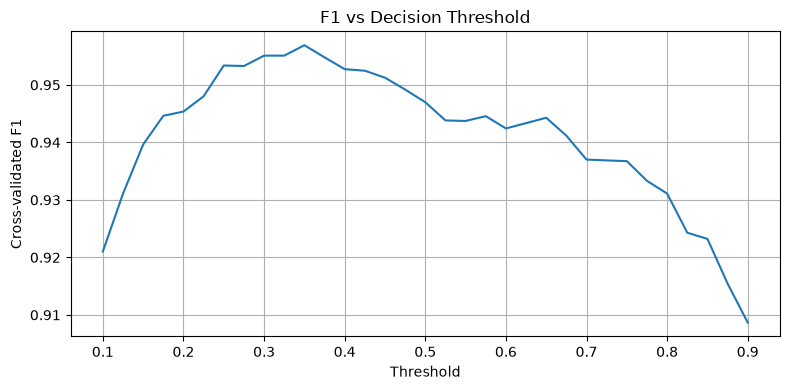

In [9]:
calibrated = CalibratedClassifierCV(
    estimator=LinearSVC(**best_pipe.named_steps["clf"].get_params()),
    cv=N_SPLITS,
    method="sigmoid",
)

proba_pipe = Pipeline(
    steps=[
        ("features", clone(best_pipe.named_steps["features"])),
        ("clf", calibrated),
    ]
)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
thr_candidates = np.linspace(0.1, 0.9, 33)


def best_threshold_cv(model, X_data: pd.DataFrame, y_data: np.ndarray, thresholds: np.ndarray, cv) -> tuple[float, np.ndarray]:
    scores = np.zeros_like(thresholds, dtype=float)

    for tr_idx, va_idx in cv.split(X_data, y_data):
        X_tr_df, X_va_df = X_data.iloc[tr_idx], X_data.iloc[va_idx]
        y_tr, y_va = y_data[tr_idx], y_data[va_idx]

        model.fit(X_tr_df, y_tr)
        proba = model.predict_proba(X_va_df)[:, 1]

        for i, threshold in enumerate(thresholds):
            preds = (proba >= threshold).astype(int)
            scores[i] += f1_score(y_va, preds)

    scores /= cv.get_n_splits()
    return float(thresholds[np.argmax(scores)]), scores


opt_thr, thr_scores = best_threshold_cv(proba_pipe, X_train_df, y_train, thr_candidates, skf)

print(f"Selected threshold (F1-optimal on CV): {opt_thr:.3f}")

fig, ax = plt.subplots()
ax.plot(thr_candidates, thr_scores)
ax.set_title("F1 vs Decision Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Cross-validated F1")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "f1_vs_threshold.png", dpi=150, bbox_inches="tight")
plt.show()


# Baseline: Logistic Regression

In [10]:
baseline = Pipeline(
    steps=[
        (
            "features",
            TfidfVectorizer(
                preprocessor=normalize_text,
                ngram_range=(1, 2),
                min_df=2,
                stop_words="english",
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

baseline.fit(X_train_df["text"], y_train)

y_pred_base = baseline.predict(X_test_df["text"])

print("Baseline LogisticRegression — Test Report")
print(classification_report(y_test, y_pred_base, target_names=["ham", "spam"], digits=4))


Baseline LogisticRegression — Test Report
              precision    recall  f1-score   support

         ham     0.9911    0.9900    0.9906       903
        spam     0.9318    0.9389    0.9354       131

    accuracy                         0.9836      1034
   macro avg     0.9615    0.9645    0.9630      1034
weighted avg     0.9836    0.9836    0.9836      1034



# Final Evaluation on Hold-out Test Set

Calibrated LinearSVC — Test Report @ selected threshold
              precision    recall  f1-score   support

         ham     0.9933    0.9911    0.9922       903
        spam     0.9398    0.9542    0.9470       131

    accuracy                         0.9865      1034
   macro avg     0.9666    0.9727    0.9696      1034
weighted avg     0.9866    0.9865    0.9865      1034



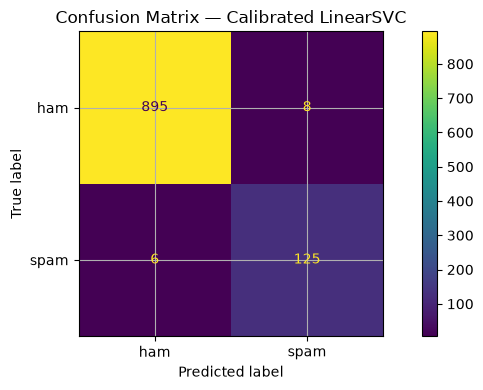

Accuracy: 0.9865
PR AUC (Average Precision): 0.9906
ROC AUC: 0.9983
Brier score (lower is better): 0.0091


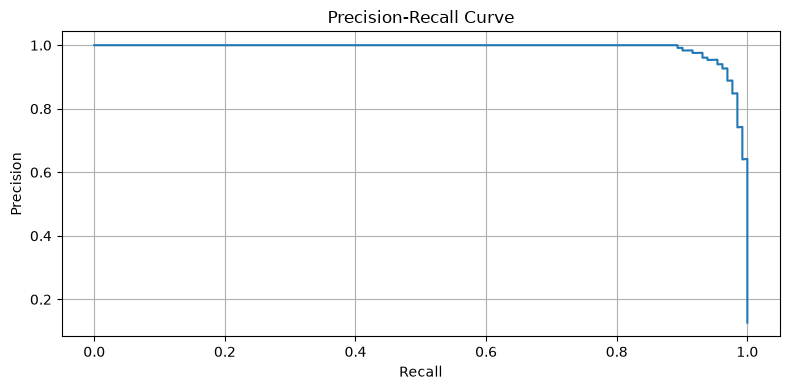

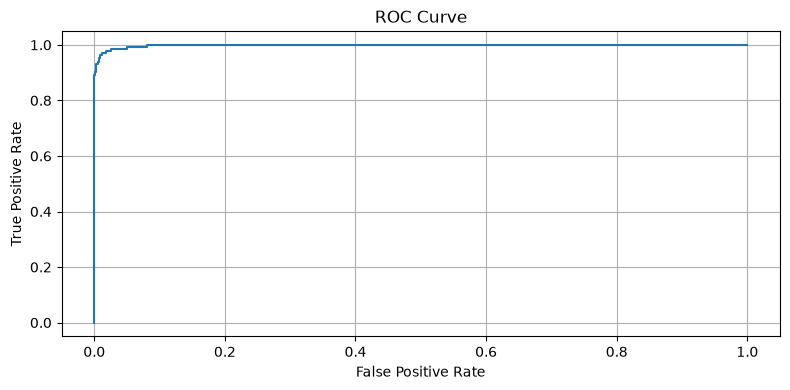

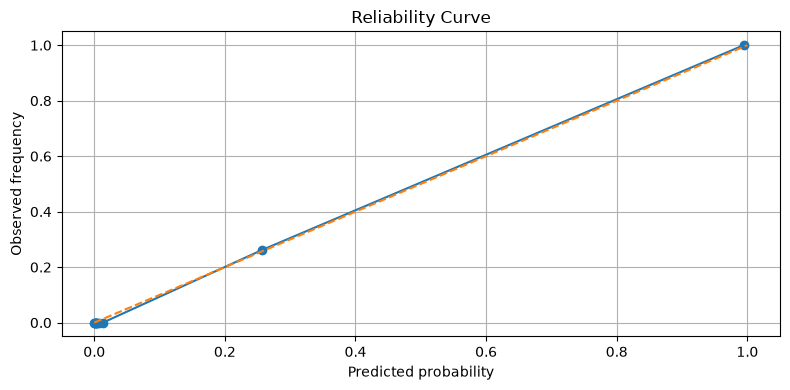

In [11]:
proba_pipe.fit(X_train_df, y_train)

y_proba = proba_pipe.predict_proba(X_test_df)[:, 1]
y_pred = (y_proba >= opt_thr).astype(int)

print("Calibrated LinearSVC — Test Report @ selected threshold")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"], digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(values_format="d")
plt.title("Confusion Matrix — Calibrated LinearSVC")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

ap = average_precision_score(y_test, y_proba)
roc = roc_auc_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"PR AUC (Average Precision): {ap:.4f}")
print(f"ROC AUC: {roc:.4f}")
print(f"Brier score (lower is better): {brier:.4f}")

precision, recall, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots()
ax.plot(recall, precision)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")
fig, ax = plt.subplots()
ax.plot(prob_pred, prob_true, marker="o")
ax.plot([0, 1], [0, 1], "--")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Reliability Curve")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()


# Metrics Summary Table

In [12]:
summary = pd.DataFrame(
    [
        {
            "NestedCV_F1_mean": float(np.mean(outer_scores)),
            "NestedCV_F1_std": float(np.std(outer_scores)),
            "Baseline_F1": float(f1_score(y_test, y_pred_base)),
            "Final_F1": float(f1_score(y_test, y_pred)),
            "Accuracy": float(accuracy_score(y_test, y_pred)),
            "PR_AUC": float(average_precision_score(y_test, y_proba)),
            "ROC_AUC": float(roc_auc_score(y_test, y_proba)),
            "Brier": float(brier_score_loss(y_test, y_proba)),
            "Opt_Threshold": float(opt_thr),
            "FP": int(((y_test == 0) & (y_pred == 1)).sum()),
            "FN": int(((y_test == 1) & (y_pred == 0)).sum()),
            "Test_Ham": int((y_test == 0).sum()),
            "Test_Spam": int((y_test == 1).sum()),
        }
    ]
).round(4)

display(summary)
summary.to_csv(ARTIFACT_DIR / "metrics_summary.csv", index=False)


,NestedCV_F1_mean,NestedCV_F1_std,Baseline_F1,Final_F1,Accuracy,PR_AUC,ROC_AUC,Brier,Opt_Threshold,FP,FN,Test_Ham,Test_Spam
0,0.9491,0.0085,0.9354,0.947,0.9865,0.9906,0.9983,0.0091,0.35,8,6,903,131


# Explainability: Top Weighted n-grams

,feature,weight
0,word____phone__,1.548818
1,word____url__,1.195743
2,word____money__,0.951644
3,word__text,0.923061
4,word__txt,0.921678
5,word__ringtone,0.752639
6,word__sale,0.752337
7,word__chat,0.731024
8,word__won,0.729032
9,word__brought,0.727516


,feature,weight
0,char__ i,-0.568218
1,word__lt,-0.531998
2,word__gt,-0.475820
3,char__ me,-0.424644
4,word__ard,-0.372389
5,word__hey,-0.358642
6,char__ u,-0.347694
7,char__ my,-0.344585
8,word__ring,-0.343249
9,char__ me,-0.334860


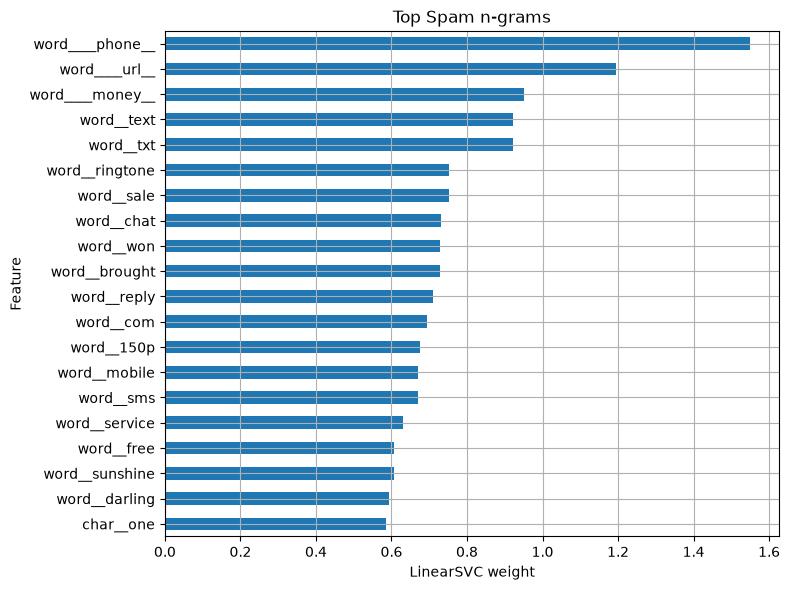

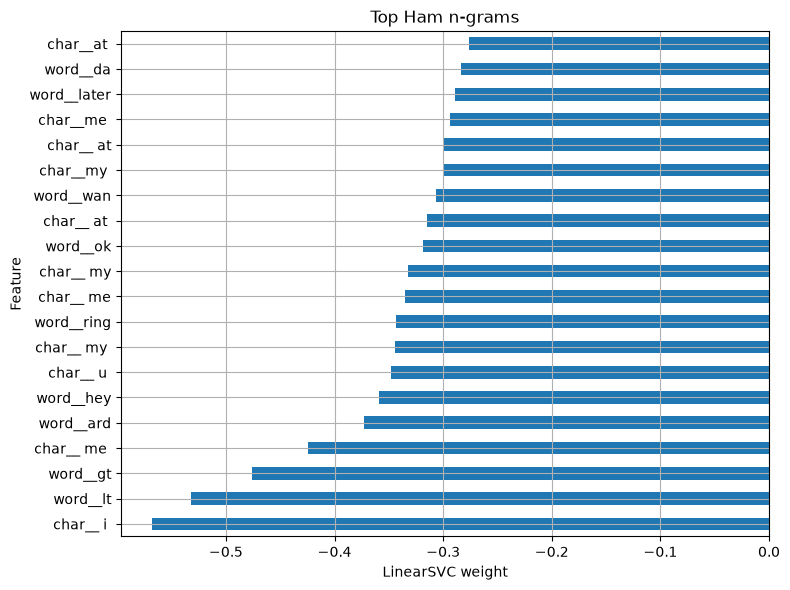

In [13]:
feat_extractor = clone(best_pipe.named_steps["features"])
Xtr_feats = feat_extractor.fit_transform(X_train_df, y_train)

svc_fresh = LinearSVC(**best_pipe.named_steps["clf"].get_params())
svc_fresh.fit(Xtr_feats, y_train)

feat_names = feat_extractor.get_feature_names_out()
coef = svc_fresh.coef_.ravel()

top_spam_idx = np.argsort(coef)[-20:][::-1]
top_ham_idx = np.argsort(coef)[:20]

top_spam = pd.DataFrame({"feature": feat_names[top_spam_idx], "weight": coef[top_spam_idx]})
top_ham = pd.DataFrame({"feature": feat_names[top_ham_idx], "weight": coef[top_ham_idx]})

display(top_spam)
display(top_ham)


def plot_top_features(data: pd.DataFrame, title: str, filename: str) -> None:
    ax = data.sort_values("weight").plot(
        kind="barh",
        x="feature",
        y="weight",
        figsize=(8, 6),
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("LinearSVC weight")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


plot_top_features(top_spam, "Top Spam n-grams", "top_spam_ngrams.png")
plot_top_features(top_ham, "Top Ham n-grams", "top_ham_ngrams.png")

top_spam.to_csv(ARTIFACT_DIR / "top_spam_ngrams.csv", index=False)
top_ham.to_csv(ARTIFACT_DIR / "top_ham_ngrams.csv", index=False)


# Robustness Check: Synthetic Obfuscation

,F1_original,F1_obfuscated,Delta_F1_abs,Delta_F1_pct
0,0.947,0.555,-0.3919,-41.3872


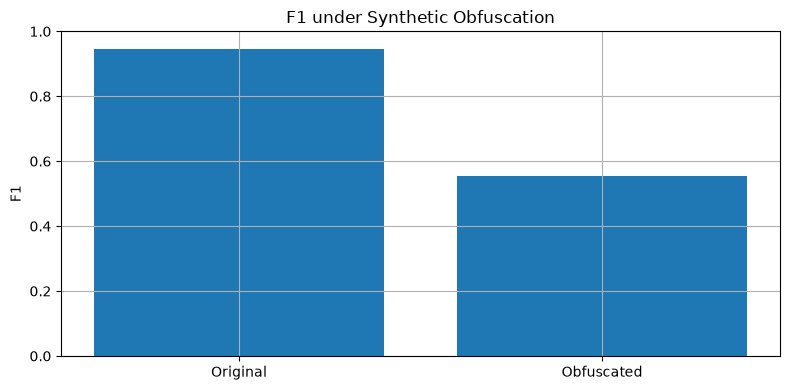

In [14]:
VOWEL_MAP = str.maketrans({"a": "@", "e": "3", "i": "1", "o": "0", "u": "ü"})


def obfuscate(text: str) -> str:
    text = str(text).translate(VOWEL_MAP)
    text = re.sub(r"s", "5", text, flags=re.IGNORECASE)
    text = re.sub(r"\bfree\b", "fr33", text, flags=re.IGNORECASE)
    text = re.sub(r"\bwin\b", "w1n", text, flags=re.IGNORECASE)
    return text


X_test_obf_df = X_test_df.copy()
X_test_obf_df["text"] = X_test_obf_df["text"].apply(obfuscate)

proba_orig = y_proba
proba_obf = proba_pipe.predict_proba(X_test_obf_df)[:, 1]

f1_orig = f1_score(y_test, (proba_orig >= opt_thr).astype(int))
f1_obf = f1_score(y_test, (proba_obf >= opt_thr).astype(int))
delta_abs = f1_obf - f1_orig
delta_pct = 100 * delta_abs / max(1e-9, f1_orig)

robustness_summary = pd.DataFrame(
    [
        {
            "F1_original": f1_orig,
            "F1_obfuscated": f1_obf,
            "Delta_F1_abs": delta_abs,
            "Delta_F1_pct": delta_pct,
        }
    ]
).round(4)

display(robustness_summary)
robustness_summary.to_csv(ARTIFACT_DIR / "robustness_summary.csv", index=False)

fig, ax = plt.subplots()
ax.bar(["Original", "Obfuscated"], [f1_orig, f1_obf])
ax.set_title("F1 under Synthetic Obfuscation")
ax.set_ylim(0, 1)
ax.set_ylabel("F1")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "f1_obfuscation.png", dpi=150, bbox_inches="tight")
plt.show()


# Error Analysis: High-confidence False Positives and False Negatives

In [15]:
def clip_text(text: str, n: int = 120) -> str:
    text = str(text)
    return (text[:n] + "...") if len(text) > n else text


test_predictions = pd.DataFrame(
    {
        "text": X_test_df["text"].values,
        "label": y_test,
        "proba_spam": y_proba,
        "pred": y_pred,
    }
)

fp = (
    test_predictions[(test_predictions["label"] == 0) & (test_predictions["pred"] == 1)]
    .sort_values("proba_spam", ascending=False)
    .head(10)
)

fn = (
    test_predictions[(test_predictions["label"] == 1) & (test_predictions["pred"] == 0)]
    .sort_values("proba_spam", ascending=True)
    .head(10)
)

print("Top 10 False Positives:")
display(fp.assign(text=fp["text"].map(clip_text))[["text", "proba_spam"]])

print("Top 10 False Negatives:")
display(fn.assign(text=fn["text"].map(clip_text))[["text", "proba_spam"]])

fp.to_csv(ARTIFACT_DIR / "top_false_positives.csv", index=False)
fn.to_csv(ARTIFACT_DIR / "top_false_negatives.csv", index=False)


Top 10 False Positives:


,text,proba_spam
327,K k:) sms chat with me.,0.782574
948,Your bill at 3 is £33.65 so thats not bad!,0.740211
29,Your daily text from me – a favour this time,0.714766
749,Glad to see your reply.,0.673923
727,"It‘s £6 to get in, is that ok?",0.574061
835,I (Career Tel) have added u as a contact on IN...,0.556026
293,Are you free now?can i call now?,0.420048
301,Please protect yourself from e-threats. SIB ne...,0.354365


Top 10 False Negatives:


,text,proba_spam
486,In The Simpsons Movie released in July 2007 na...,0.022912
690,"Latest News! Police station toilet stolen, cop...",0.043234
801,Would you like to see my XXX pics they are so ...,0.074739
992,Burger King - Wanna play footy at a top stadiu...,0.093850
544,Xmas & New Years Eve tickets are now on sale f...,0.192856
437,Babe: U want me dont u baby! Im nasty and have...,0.283437


## Limitations and Next Steps

- The model is strong on clean SMS text and performs well on the held-out test set.
- The synthetic obfuscation check shows a sharp F1 drop, which is a practical weakness of token and character n-gram models under adversarial spelling changes.
- The decision threshold is selected using cross-validation on the training split, not by tuning directly on the test split.

Recommended next steps:

- Add obfuscated and augmented spam examples during training.
- Compare against lightweight embedding models such as FastText or DistilBERT.
- Add a small review workflow for borderline predictions instead of auto-blocking every message.
- Package the calibrated model behind a minimal FastAPI endpoint or Streamlit demo.


# Export Artifacts and Metadata

In [16]:
ARTIFACT_DIR = Path(ARTIFACT_DIR)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

metrics_row = summary.iloc[0].to_dict()
robustness_row = robustness_summary.iloc[0].to_dict()

metadata = {
    "created_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "author": "parth2024-tech",
    "dataset": "SMS Spam Collection",
    "model_type": "LinearSVC + sigmoid calibration",
    "random_seed": RANDOM_SEED,
    "n_iter_search": N_ITER_SEARCH,
    "n_splits": N_SPLITS,
    "opt_threshold": float(opt_thr),
    "label_map": {str(k): int(v) for k, v in label_map.items()},
    "data": {
        "raw_rows": int(raw_rows),
        "duplicate_rows_removed": int(duplicate_rows),
        "missing_rows_removed": int(missing_rows),
        "invalid_label_rows_removed": int(invalid_label_rows),
        "final_rows": int(len(df)),
    },
    "vectorizers": {
        "word": {
            "analyzer": "word",
            "ngram_range": list(word_tfidf.ngram_range),
            "min_df": int(word_tfidf.min_df) if isinstance(word_tfidf.min_df, int) else word_tfidf.min_df,
            "stop_words": "english",
            "sublinear_tf": bool(getattr(word_tfidf, "sublinear_tf", False)),
        },
        "char": {
            "analyzer": "char_wb",
            "ngram_range": list(char_tfidf.ngram_range),
            "min_df": int(char_tfidf.min_df) if isinstance(char_tfidf.min_df, int) else char_tfidf.min_df,
            "sublinear_tf": bool(getattr(char_tfidf, "sublinear_tf", False)),
        },
    },
    "versions": {
        "python": sys.version.split()[0],
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "matplotlib": plt.matplotlib.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
    "metrics": {k: float(v) if isinstance(v, (int, float, np.integer, np.floating)) else v for k, v in metrics_row.items()},
    "robustness": {k: float(v) if isinstance(v, (int, float, np.integer, np.floating)) else v for k, v in robustness_row.items()},
    "best_params": final_search.best_params_,
}

joblib.dump(best_pipe, ARTIFACT_DIR / "sms_spam_linear_svc.joblib", compress=3)
joblib.dump(proba_pipe, ARTIFACT_DIR / "sms_spam_calibrated.joblib", compress=3)
joblib.dump(best_pipe.named_steps["features"], ARTIFACT_DIR / "tfidf_features.joblib", compress=3)

with open(ARTIFACT_DIR / "metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())
print("Files:")
for file_path in sorted(ARTIFACT_DIR.iterdir()):
    if file_path.is_file():
        print("-", file_path.name)


/tmp/ipykernel_4997/1364208591.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",


Artifacts saved to: /home/thor/Downloads/sms-spam-detection-main/artifacts
Files:
- README.md
- calibration_curve.png
- char_len_hist.png
- class_balance.png
- confusion_matrix.png
- f1_obfuscation.png
- f1_vs_threshold.png
- metadata.json
- metrics_summary.csv
- precision_recall_curve.png
- robustness_summary.csv
- roc_curve.png
- sms_spam_calibrated.joblib
- sms_spam_linear_svc.joblib
- tfidf_features.joblib
- top_false_negatives.csv
- top_false_positives.csv
- top_ham_ngrams.csv
- top_ham_ngrams.png
- top_spam_ngrams.csv
- top_spam_ngrams.png
- word_len_hist.png


# Inference Helper

In [17]:
def predict_messages(messages, threshold: float | None = None) -> tuple[np.ndarray, np.ndarray]:
    if isinstance(messages, str):
        messages = [messages]

    if threshold is None:
        try:
            with open(ARTIFACT_DIR / "metadata.json", "r", encoding="utf-8") as file:
                saved_metadata = json.load(file)
            threshold = float(saved_metadata.get("opt_threshold", 0.5))
        except Exception:
            threshold = float(opt_thr)

    infer_df = pd.DataFrame({"text": list(messages)})
    probs = proba_pipe.predict_proba(infer_df)[:, 1]
    preds = (probs >= threshold).astype(int)

    return preds, probs


smoke_test = pd.DataFrame(
    {
        "text": [
            "Congratulations! You won a £1000 prize. Text CLAIM now to receive your reward.",
            "Hey, are we still meeting for dinner tonight?",
        ],
        "expected_label": ["spam", "ham"],
    }
)

preds, probs = predict_messages(smoke_test["text"].tolist())

smoke_test["predicted_label"] = np.where(preds == 1, "spam", "ham")
smoke_test["spam_probability"] = probs
smoke_test["matches_expected"] = smoke_test["expected_label"].eq(smoke_test["predicted_label"])

display(smoke_test.round({"spam_probability": 3}))


,text,expected_label,predicted_label,spam_probability,matches_expected
0,Congratulations! You won a £1000 prize. Text C...,spam,spam,0.996,True
1,"Hey, are we still meeting for dinner tonight?",ham,ham,0.001,True


## Reproducibility Check

In [18]:
ARTIFACT_DIR = Path("./artifacts")

assert (ARTIFACT_DIR / "sms_spam_calibrated.joblib").exists(), "Missing calibrated model artifact."
assert (ARTIFACT_DIR / "metadata.json").exists(), "Missing metadata.json."

with open(ARTIFACT_DIR / "metadata.json", "r", encoding="utf-8") as file:
    saved_metadata = json.load(file)

opt_thr_meta = float(saved_metadata.get("opt_threshold", 0.5))
calibrated_reload = joblib.load(ARTIFACT_DIR / "sms_spam_calibrated.joblib")

sample_df = pd.DataFrame({"text": ["win a free prize now"]})
proba_reload = calibrated_reload.predict_proba(sample_df)[:, 1][0]
pred_reload = int(proba_reload >= opt_thr_meta)

print(f"Reloaded proba: {proba_reload:.3f} | threshold: {opt_thr_meta:.3f} | pred: {pred_reload}")

repeat_df = pd.DataFrame({"text": ["Can you call me when you get home?"]})
p1 = calibrated_reload.predict_proba(repeat_df)[:, 1][0]
p2 = calibrated_reload.predict_proba(repeat_df)[:, 1][0]

assert abs(p1 - p2) < 1e-12, "Non-deterministic inference detected."
print("Deterministic inference: OK")


Reloaded proba: 0.891 | threshold: 0.350 | pred: 1
Deterministic inference: OK


## Summary and Conclusion

**What we built:** a reproducible SMS spam detection workflow using dual TF-IDF features, LinearSVC, probability calibration, and a validation-selected threshold.

**Hold-out performance:** the calibrated model reaches strong F1, PR AUC, ROC AUC, and Brier score results on the reserved test split.

**Operational view:** false positives and false negatives are exported for manual review, and the threshold is stored in metadata for consistent inference.

**Main limitation:** performance drops sharply under synthetic obfuscation, so production use should include adversarial examples, monitoring, and a review path for borderline messages.

**Reusable outputs:** model artifacts, metrics, metadata, plots, n-gram explanations, robustness results, and error-analysis tables are saved under `./artifacts/`.


In [19]:
display(
    Markdown(
        f"""**Final decision threshold:** `{opt_thr:.3f}`

**Publish note:** this notebook is ready as a strong Kaggle ML notebook after rerunning all cells and saving the output.
"""
    )
)


**Final decision threshold:** `0.350`

**Publish note:** this notebook is ready as a strong Kaggle ML notebook after rerunning all cells and saving the output.
